# Vaccination Data — Exploratory Data Analysis




In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (9,4.5), 'axes.spines.top': False, 'axes.spines.right': False})

DATA_DIR = '.' if os.path.exists('coverage-data.xlsx') else '/mnt/user-data/uploads'
print('Reading data from:', DATA_DIR)

FILES = {
    'coverage':        'coverage-data.xlsx',
    'incidence':       'incidence-rate-data.xlsx',
    'reported_cases':  'reported-cases-data.xlsx',
    'vaccine_intro':   'vaccine-introduction-data.xlsx',
    'vaccine_schedule':'vaccine-schedule-data.xlsx',
}


Reading data from: /mnt/user-data/uploads


## 1. Load every dataset and get a first look at shape & structure

In [2]:

raw = {}
for name, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_excel(path, sheet_name='Data')
    raw[name] = df
    print(f"{name:18s} -> {df.shape[0]:>7,} rows x {df.shape[1]} cols   |  columns: {list(df.columns)}")


coverage           -> 399,859 rows x 11 cols   |  columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
incidence          ->  84,946 rows x 8 cols   |  columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
reported_cases     ->  84,870 rows x 7 cols   |  columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
vaccine_intro      -> 138,321 rows x 6 cols   |  columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
vaccine_schedule   ->   8,053 rows x 12 cols   |  columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [3]:

raw['coverage'].head()


## 2. Missing-value profile across all five datasets

A quick way to spot structural issues (like the trailing "Created: ..." metadata
row every WHO export carries) is to look at which single row is responsible for
almost all of the missing values in the key/id columns.

In [4]:

missing_summary = []
for name, df in raw.items():
    miss = df.isna().sum()
    pct = (miss / len(df) * 100).round(2)
    missing_summary.append(pd.DataFrame({'dataset': name, 'column': miss.index,
                                          'missing': miss.values, 'missing_pct': pct.values}))
missing_df = pd.concat(missing_summary, ignore_index=True)
missing_df[missing_df['missing'] > 0].sort_values(['dataset','missing_pct'], ascending=[True, False])


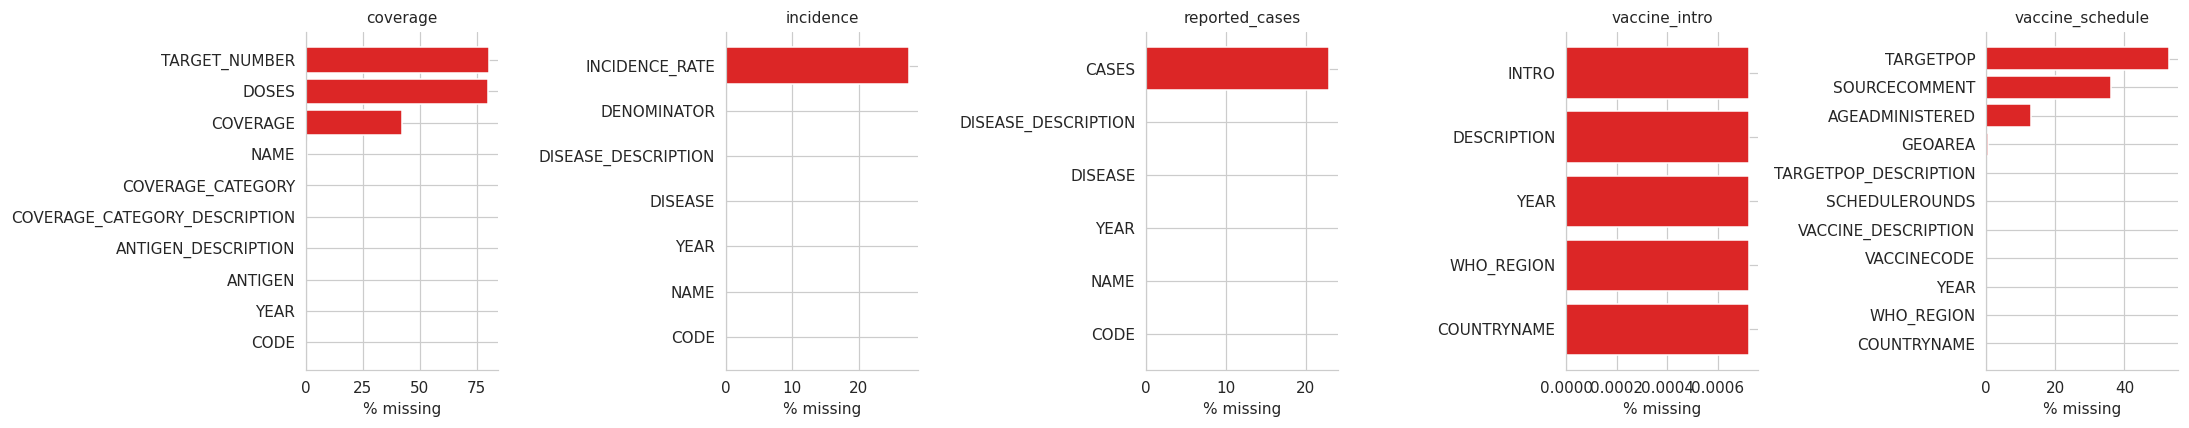

In [5]:

fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, (name, df) in zip(axes, raw.items()):
    miss_pct = df.isna().mean() * 100
    miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=True)
    if len(miss_pct):
        ax.barh(miss_pct.index, miss_pct.values, color='#dc2626')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('% missing')
plt.tight_layout()
plt.show()


In [6]:

# The last row of every file is a trailing "Created: <timestamp>" metadata row
# left over from the WHO export - not a real data record. Confirm and inspect it:
print(raw['coverage'].tail(1).to_string())


                                GROUP CODE NAME  YEAR ANTIGEN ANTIGEN_DESCRIPTION COVERAGE_CATEGORY COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER  DOSES  COVERAGE
399858  Created: 2025-02-01 16:00 UTC  NaN  NaN   NaN     NaN                 NaN               NaN                           NaN            NaN    NaN       NaN


## 3. Dataset 1 — Coverage data

Vaccine coverage (%) by country, year, and antigen. This is the largest and most
important file for the rest of the project.

In [7]:

cov = raw['coverage'].iloc[:-1].copy()   # drop the trailing metadata row
print(cov['GROUP'].value_counts())
print()
print('Year range:', cov['YEAR'].min(), '-', cov['YEAR'].max())
print('Distinct countries:', cov.loc[cov['GROUP']=='COUNTRIES','NAME'].nunique())
print('Distinct antigens:', cov['ANTIGEN'].nunique())


GROUP
COUNTRIES             381041
UNICEF_REGIONS          4660
WB_LONG                 3767
WHO_REGIONS             3757
WB_SHORT                2564
DEVELOPMENT_STATUS      2230
GAVI_PHASE5             1194
GLOBAL                   645
Name: count, dtype: int64

Year range: 1980.0 - 2023.0
Distinct countries: 214
Distinct antigens: 69


In [8]:

cov_c = cov[cov['GROUP']=='COUNTRIES'].copy()
cov_c['COVERAGE'] = pd.to_numeric(cov_c['COVERAGE'], errors='coerce')
print(cov_c['COVERAGE'].describe())


count    211710.000000
mean         80.725039
std          76.822795
min           0.000000
25%          73.000000
50%          90.000000
75%          96.600000
max       32000.000000
Name: COVERAGE, dtype: float64


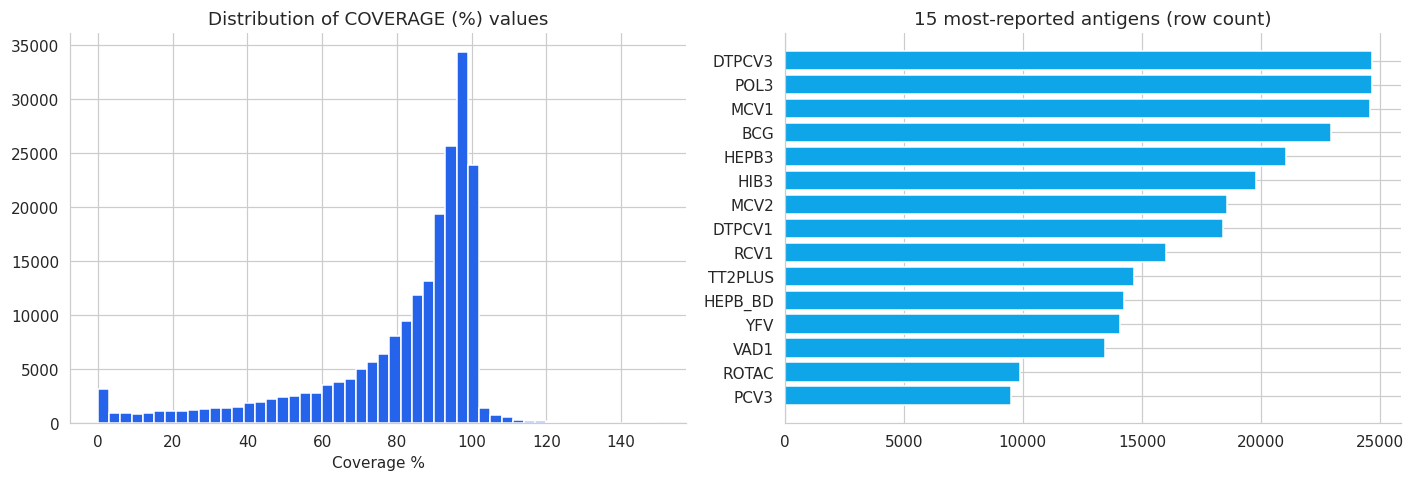

In [9]:

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
cov_c['COVERAGE'].dropna().pipe(lambda s: s[s.between(0,150)]).hist(bins=50, ax=ax[0], color='#2563eb')
ax[0].set_title('Distribution of COVERAGE (%) values')
ax[0].set_xlabel('Coverage %')

top_antigens = cov_c['ANTIGEN'].value_counts().head(15)
ax[1].barh(top_antigens.index[::-1], top_antigens.values[::-1], color='#0ea5e9')
ax[1].set_title('15 most-reported antigens (row count)')
plt.tight_layout(); plt.show()


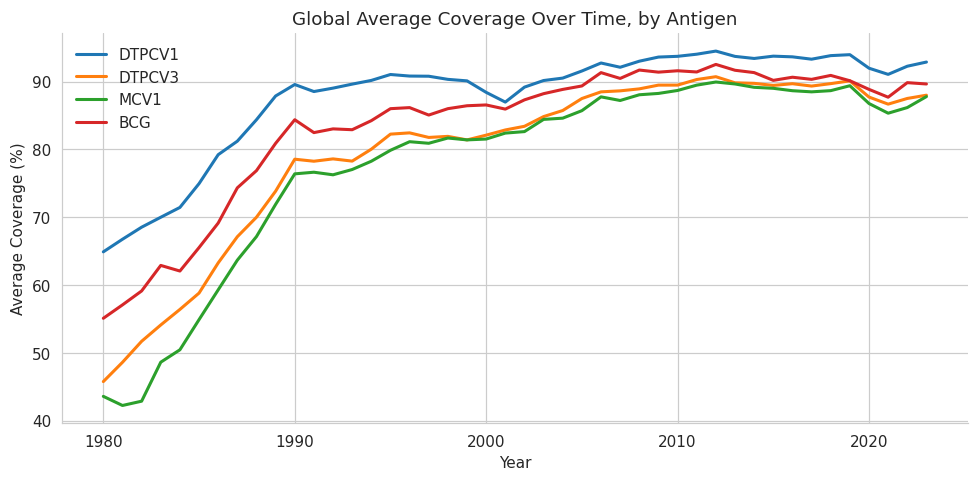

In [10]:

# Global average coverage trend over time, for the 4 antigens most central to the project
key_antigens = ['DTPCV1','DTPCV3','MCV1','BCG']
trend = (cov_c[cov_c['ANTIGEN'].isin(key_antigens)]
         .groupby(['YEAR','ANTIGEN'])['COVERAGE'].mean().reset_index())

fig, ax = plt.subplots()
for ant in key_antigens:
    sub = trend[trend['ANTIGEN']==ant]
    ax.plot(sub['YEAR'], sub['COVERAGE'], label=ant, linewidth=2)
ax.set_title('Global Average Coverage Over Time, by Antigen')
ax.set_xlabel('Year'); ax.set_ylabel('Average Coverage (%)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 4. Dataset 2 — Incidence rate data

In [11]:

inc = raw['incidence'].iloc[:-1].copy()
inc_c = inc[inc['GROUP']=='COUNTRIES'].copy()
inc_c['INCIDENCE_RATE'] = pd.to_numeric(inc_c['INCIDENCE_RATE'], errors='coerce')
print('Diseases tracked:', sorted(inc_c['DISEASE'].unique()))
print()
print(inc_c['INCIDENCE_RATE'].describe())


Diseases tracked: ['CRS', 'DIPHTHERIA', 'INVASIVE_MENING', 'JAPENC', 'MEASLES', 'MUMPS', 'NTETANUS', 'PERTUSSIS', 'POLIO', 'RUBELLA', 'TTETANUS', 'TYPHOID', 'YFEVER']

count    58909.000000
mean       111.258473
std       1012.772661
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max      69101.300000
Name: INCIDENCE_RATE, dtype: float64


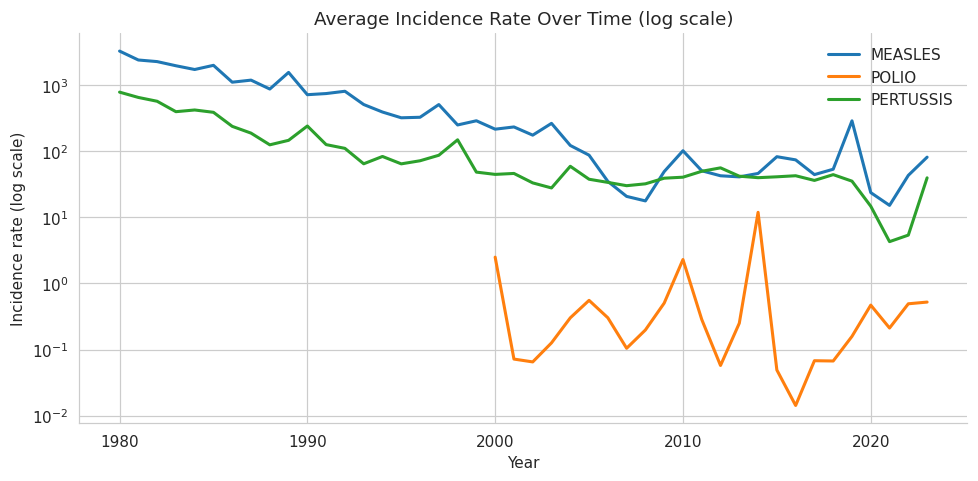

In [12]:

fig, ax = plt.subplots()
for disease in ['MEASLES','POLIO','PERTUSSIS']:
    sub = inc_c[inc_c['DISEASE']==disease].groupby('YEAR')['INCIDENCE_RATE'].mean()
    ax.plot(sub.index, sub.values, label=disease, linewidth=2)
ax.set_yscale('log')
ax.set_title('Average Incidence Rate Over Time (log scale)')
ax.set_xlabel('Year'); ax.set_ylabel('Incidence rate (log scale)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 5. Dataset 3 — Reported cases data

In [13]:

rep = raw['reported_cases'].iloc[:-1].copy()
rep_c = rep[rep['GROUP']=='COUNTRIES'].copy()
rep_c['CASES'] = pd.to_numeric(rep_c['CASES'], errors='coerce')
print('Diseases tracked:', sorted(rep_c['DISEASE'].unique()))
print()
by_disease = rep_c.groupby('DISEASE')['CASES'].sum().sort_values(ascending=False)
print(by_disease)


Diseases tracked: ['CRS', 'DIPHTHERIA', 'INVASIVE_MENING', 'JAPENC', 'MEASLES', 'MUMPS', 'NTETANUS', 'PERTUSSIS', 'POLIO', 'RUBELLA', 'TTETANUS', 'TYPHOID', 'YFEVER']

DISEASE
MEASLES            48041277.0
PERTUSSIS          17698484.0
MUMPS              12116382.0
TYPHOID            10384456.0
RUBELLA             5554009.0
TTETANUS            1629693.0
DIPHTHERIA           969425.0
POLIO                541099.0
NTETANUS             501278.0
JAPENC                75184.0
INVASIVE_MENING       69082.0
YFEVER                44226.0
CRS                    9556.0
Name: CASES, dtype: float64


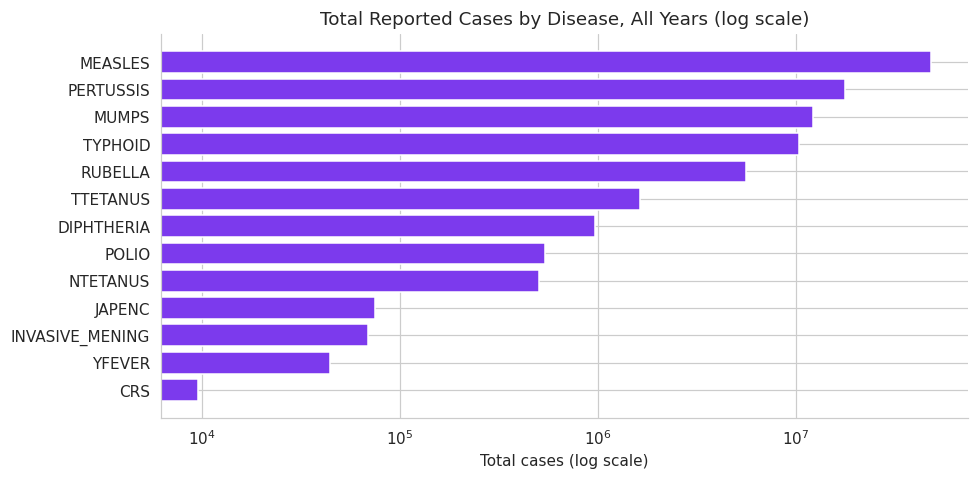

In [14]:

fig, ax = plt.subplots()
ax.barh(by_disease.index[::-1], by_disease.values[::-1], color='#7c3aed')
ax.set_title('Total Reported Cases by Disease, All Years (log scale)')
ax.set_xscale('log')
ax.set_xlabel('Total cases (log scale)')
plt.tight_layout(); plt.show()


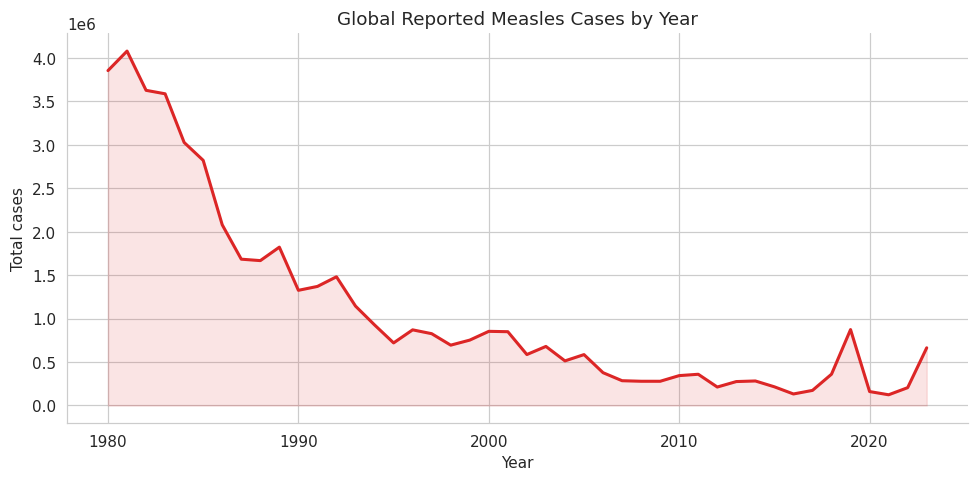

In [15]:

global_measles = rep_c[rep_c['DISEASE']=='MEASLES'].groupby('YEAR')['CASES'].sum()
fig, ax = plt.subplots()
ax.plot(global_measles.index, global_measles.values, color='#dc2626', linewidth=2)
ax.fill_between(global_measles.index, global_measles.values, color='#dc2626', alpha=0.12)
ax.set_title('Global Reported Measles Cases by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Total cases')
plt.tight_layout(); plt.show()


## 6. Dataset 4 — Vaccine introduction data

In [16]:

vi = raw['vaccine_intro'].iloc[:-1].copy()
print(vi['INTRO'].value_counts(dropna=False))
print()
print('Distinct vaccines tracked:', vi['DESCRIPTION'].nunique())
print(sorted(vi['DESCRIPTION'].dropna().unique())[:15])


INTRO
No                97695
Yes               37844
Yes (R)            1708
Yes (P)             825
High risk area      118
Yes (A)              67
ND                   39
Yes (O)              22
Yes (D)               2
Name: count, dtype: int64

Distinct vaccines tracked: 21
['HPV (Human Papilloma Virus) vaccine', 'HepB birth dose', 'Hepatitis A vaccine', 'Hepatitis B vaccine', 'Hib (Haemophilus influenzae type B) vaccine', 'IPV (Inactivated polio vaccine)', 'IPV (Inactivated polio vaccine) 2nd dose', 'Japanese Encephalitis', 'Malaria vaccine', 'Measles-containing vaccine 2nd dose', 'Meningococcal meningitis vaccines (all strains)', 'Mumps vaccine', 'PCV (Pneumococcal conjugate vaccine)', 'PPV (Pneumococcal polysaccharide vaccine)', 'Rotavirus vaccine']


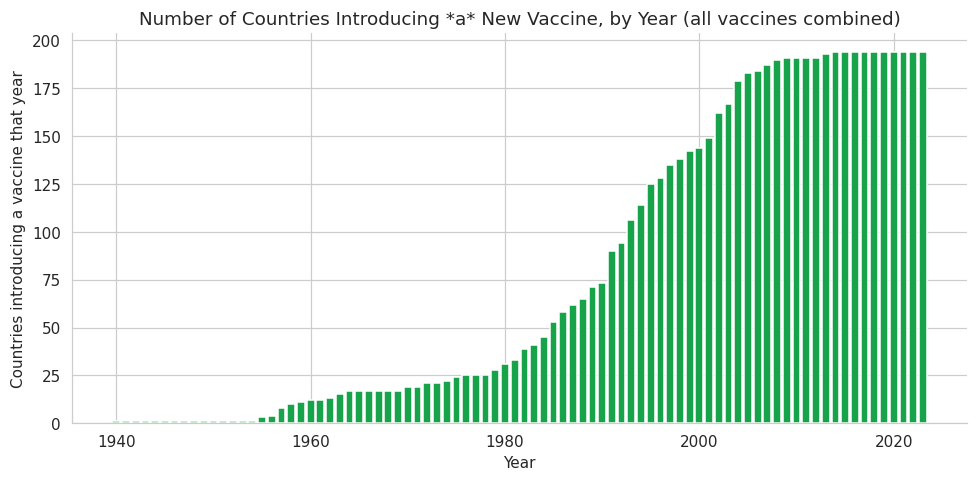

In [17]:

intros_per_year = (vi[vi['INTRO']=='Yes']
                    .groupby('YEAR')['ISO_3_CODE'].nunique())
fig, ax = plt.subplots()
ax.bar(intros_per_year.index, intros_per_year.values, color='#16a34a')
ax.set_title('Number of Countries Introducing *a* New Vaccine, by Year (all vaccines combined)')
ax.set_xlabel('Year'); ax.set_ylabel('Countries introducing a vaccine that year')
plt.tight_layout(); plt.show()


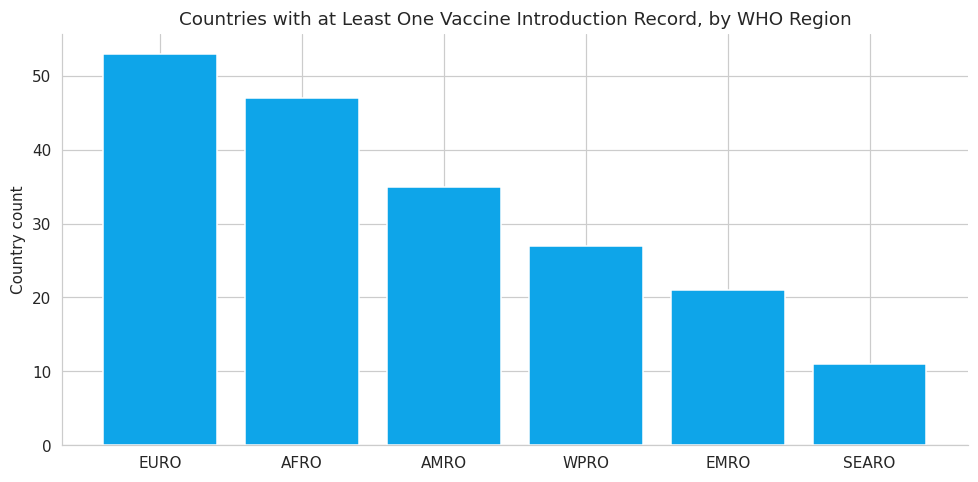

In [18]:

by_region = (vi[vi['INTRO']=='Yes'].groupby('WHO_REGION')['ISO_3_CODE'].nunique()
             .sort_values(ascending=False))
fig, ax = plt.subplots()
ax.bar(by_region.index, by_region.values, color='#0ea5e9')
ax.set_title('Countries with at Least One Vaccine Introduction Record, by WHO Region')
ax.set_ylabel('Country count')
plt.tight_layout(); plt.show()


## 7. Dataset 5 — Vaccine schedule data

In [19]:

vs = raw['vaccine_schedule'].iloc[:-1].copy()
vs['SCHEDULEROUNDS'] = pd.to_numeric(vs['SCHEDULEROUNDS'], errors='coerce')
print(vs['SCHEDULEROUNDS'].describe())
print()
print(vs['TARGETPOP_DESCRIPTION'].value_counts().head(10))


count    8052.000000
mean        2.053403
std         1.316560
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         7.000000
Name: SCHEDULEROUNDS, dtype: float64

TARGETPOP_DESCRIPTION
General/routine                          4695
Risk group(s)                            1247
Adults                                    658
Pregnant women                            535
Health workers                            330
Travellers                                208
HPV for females only                      152
HPV administered to females and males     124
Catch-up children                          84
Catch-up adults                            19
Name: count, dtype: int64


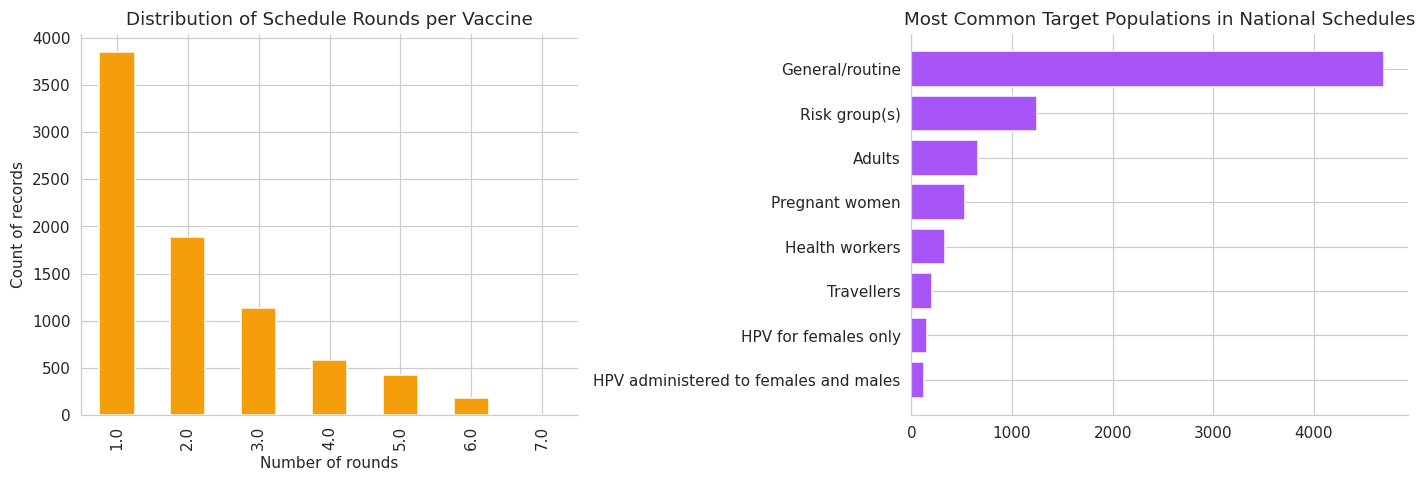

In [20]:

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
vs['SCHEDULEROUNDS'].dropna().value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#f59e0b')
ax[0].set_title('Distribution of Schedule Rounds per Vaccine')
ax[0].set_xlabel('Number of rounds'); ax[0].set_ylabel('Count of records')

top_target = vs['TARGETPOP_DESCRIPTION'].value_counts().head(8)
ax[1].barh(top_target.index[::-1], top_target.values[::-1], color='#a855f7')
ax[1].set_title('Most Common Target Populations in National Schedules')
plt.tight_layout(); plt.show()


## 8. Cross-dataset check — coverage vs. incidence relationship

A first look at whether the two "outcome" datasets (coverage and incidence) actually
move together at the country-year level, before any correlation is computed formally
in the SQL analysis.

Matched country-year rows: 21399
Pearson correlation (MCV1 coverage vs measles incidence): -0.204


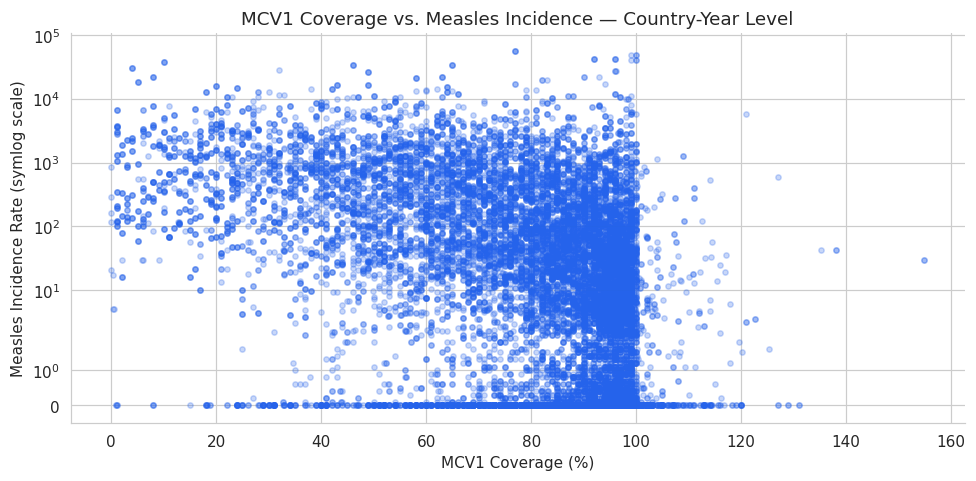

In [21]:

merged = pd.merge(
    cov_c[cov_c['ANTIGEN']=='MCV1'][['CODE','YEAR','COVERAGE']],
    inc_c[inc_c['DISEASE']=='MEASLES'][['CODE','YEAR','INCIDENCE_RATE']],
    on=['CODE','YEAR'], how='inner'
).dropna()

print('Matched country-year rows:', len(merged))
print('Pearson correlation (MCV1 coverage vs measles incidence):',
      round(merged['COVERAGE'].corr(merged['INCIDENCE_RATE']), 3))

fig, ax = plt.subplots()
ax.scatter(merged['COVERAGE'], merged['INCIDENCE_RATE'], alpha=0.25, s=12, color='#2563eb')
ax.set_yscale('symlog')
ax.set_xlabel('MCV1 Coverage (%)'); ax.set_ylabel('Measles Incidence Rate (symlog scale)')
ax.set_title('MCV1 Coverage vs. Measles Incidence — Country-Year Level')
plt.tight_layout(); plt.show()


## 9. Data Cleaning — building the cleaned datasets

The EDA above surfaced five concrete issues that need to be fixed before these
tables are loaded into the SQL database: a trailing metadata row, mixed
country/region/global rows sharing one table, numeric columns stored as text,
inconsistent whitespace in categorical/id columns, and (potentially) duplicate
rows. This section builds a `clean_<name>` DataFrame for each dataset, applying
one clear, reproducible rule per issue, then validates and exports the results.

In [ ]:
def strip_strings(df):
    """Trim leading/trailing whitespace on every object (string) column."""
    out = df.copy()
    obj_cols = out.select_dtypes(include='object').columns
    for c in obj_cols:
        out[c] = out[c].str.strip()
    return out


def report_cleaning(name, before, after, key_cols):
    """Print a short before/after summary for one cleaned dataset."""
    dup_rows = before.duplicated().sum()
    dup_keys = after.duplicated(subset=key_cols).sum()
    print(f"{name:18s} raw={len(before):>7,} rows -> clean={len(after):>7,} rows | "
          f"exact dup rows dropped={dup_rows:,} | remaining dup keys={dup_keys:,}")


### 9.1 Coverage data

`COVERAGE`, `TARGET_NUMBER` and `DOSES` are read in as text because a handful of
rows use non-numeric placeholders; converting them with `errors='coerce'`
preserves genuine not-reported values as `NaN` rather than guessing at a number
(per the EDA finding above — missing coverage must never be imputed as 0).

In [ ]:
clean_coverage = strip_strings(cov)

for col in ['COVERAGE', 'TARGET_NUMBER', 'DOSES']:
    clean_coverage[col] = pd.to_numeric(clean_coverage[col], errors='coerce')
clean_coverage['YEAR'] = pd.to_numeric(clean_coverage['YEAR'], errors='coerce').astype('Int64')

# A COVERAGE value can only be a valid percentage; flag (don't silently drop) anything outside 0-100
bad_pct = clean_coverage['COVERAGE'].notna() & ~clean_coverage['COVERAGE'].between(0, 100)
print(f"Coverage values outside 0-100%: {bad_pct.sum():,} (kept, but worth flagging downstream)")

clean_coverage = clean_coverage.drop_duplicates().reset_index(drop=True)
report_cleaning('coverage', cov, clean_coverage, key_cols=['GROUP','CODE','YEAR','ANTIGEN','COVERAGE_CATEGORY'])


### 9.2 Incidence rate data

In [ ]:
clean_incidence = strip_strings(inc)
clean_incidence['INCIDENCE_RATE'] = pd.to_numeric(clean_incidence['INCIDENCE_RATE'], errors='coerce')
clean_incidence['DENOMINATOR'] = pd.to_numeric(clean_incidence['DENOMINATOR'], errors='coerce')
clean_incidence['YEAR'] = pd.to_numeric(clean_incidence['YEAR'], errors='coerce').astype('Int64')

neg_rate = clean_incidence['INCIDENCE_RATE'].notna() & (clean_incidence['INCIDENCE_RATE'] < 0)
print(f"Negative incidence rates found: {neg_rate.sum():,}")
clean_incidence.loc[neg_rate, 'INCIDENCE_RATE'] = np.nan  # a negative rate is a data error, not a real value

clean_incidence = clean_incidence.drop_duplicates().reset_index(drop=True)
report_cleaning('incidence', inc, clean_incidence, key_cols=['GROUP','CODE','YEAR','DISEASE'])


### 9.3 Reported cases data

In [ ]:
clean_reported_cases = strip_strings(rep)
clean_reported_cases['CASES'] = pd.to_numeric(clean_reported_cases['CASES'], errors='coerce')
clean_reported_cases['YEAR'] = pd.to_numeric(clean_reported_cases['YEAR'], errors='coerce').astype('Int64')

neg_cases = clean_reported_cases['CASES'].notna() & (clean_reported_cases['CASES'] < 0)
print(f"Negative case counts found: {neg_cases.sum():,}")
clean_reported_cases.loc[neg_cases, 'CASES'] = np.nan

clean_reported_cases = clean_reported_cases.drop_duplicates().reset_index(drop=True)
report_cleaning('reported_cases', rep, clean_reported_cases, key_cols=['GROUP','CODE','YEAR','DISEASE'])


### 9.4 Vaccine introduction data

`INTRO` is a free-text status column (e.g. `Yes` / `No` / blank); standardizing its
casing avoids silently splitting the same status into multiple groups downstream.

In [ ]:
clean_vaccine_intro = strip_strings(vi)
clean_vaccine_intro['YEAR'] = pd.to_numeric(clean_vaccine_intro['YEAR'], errors='coerce').astype('Int64')

print('INTRO values before standardizing:', sorted(clean_vaccine_intro['INTRO'].dropna().unique()))
clean_vaccine_intro['INTRO'] = clean_vaccine_intro['INTRO'].str.title()

clean_vaccine_intro = clean_vaccine_intro.drop_duplicates().reset_index(drop=True)
report_cleaning('vaccine_intro', vi, clean_vaccine_intro, key_cols=['ISO_3_CODE','YEAR','DESCRIPTION'])


### 9.5 Vaccine schedule data

In [ ]:
clean_vaccine_schedule = strip_strings(vs)
clean_vaccine_schedule['SCHEDULEROUNDS'] = pd.to_numeric(clean_vaccine_schedule['SCHEDULEROUNDS'], errors='coerce')
clean_vaccine_schedule['YEAR'] = pd.to_numeric(clean_vaccine_schedule['YEAR'], errors='coerce').astype('Int64')

clean_vaccine_schedule = clean_vaccine_schedule.drop_duplicates().reset_index(drop=True)
report_cleaning('vaccine_schedule', vs, clean_vaccine_schedule,
                 key_cols=['ISO_3_CODE','YEAR','VACCINECODE','TARGETPOP'])


### 9.6 Post-cleaning validation

A final pass across all five cleaned tables: confirm the numeric columns actually
converted cleanly (no unexpected all-NaN columns), and confirm no row count grew
during cleaning (cleaning should only ever remove or correct rows, never add them).

In [ ]:
clean_datasets = {
    'coverage': clean_coverage,
    'incidence': clean_incidence,
    'reported_cases': clean_reported_cases,
    'vaccine_intro': clean_vaccine_intro,
    'vaccine_schedule': clean_vaccine_schedule,
}
raw_row_counts = {'coverage': len(cov), 'incidence': len(inc), 'reported_cases': len(rep),
                   'vaccine_intro': len(vi), 'vaccine_schedule': len(vs)}

for name, df in clean_datasets.items():
    assert len(df) <= raw_row_counts[name], f"{name}: cleaning must not add rows"
    null_cols = [c for c in df.columns if df[c].isna().all()]
    print(f"{name:18s} dtypes ok, {len(df):>7,} rows, fully-null columns: {null_cols or 'none'}")


### 9.7 Export cleaned datasets

Write each cleaned table to CSV so the SQL loading step reads from a fixed,
versioned snapshot rather than re-deriving cleaning logic itself.

In [ ]:
OUT_DIR = '/mnt/user-data/outputs' if os.path.exists('/mnt/user-data/outputs') else '.'
os.makedirs(OUT_DIR, exist_ok=True)

for name, df in clean_datasets.items():
    out_path = os.path.join(OUT_DIR, f'{name}_clean.csv')
    df.to_csv(out_path, index=False)
    print('Wrote', out_path, f'({len(df):,} rows)')


In [ ]:
Github Link : https://github.com/KartikJoshi1509/vaccination-eda